In [ ]:
!pip install -q ultralytics kagglehub opencv-python pandas scikit-learn matplotlib

In [ ]:
import kagglehub
import os

# Unduh dataset versi terbaru
path = kagglehub.dataset_download("faizalkarim/flood-area-segmentation")
print(f"Dataset berhasil diunduh dan tersimpan di:\n{path}")

# Setup variabel path sumber
csv_path = os.path.join(path, "metadata.csv")
image_dir = os.path.join(path, "Image")
mask_dir = os.path.join(path, "Mask")

100%|██████████| 107M/107M [00:00<00:00, 134MB/s]

Extracting files...


Dataset berhasil diunduh dan tersimpan di:
/root/.cache/kagglehub/datasets/faizalkarim/flood-area-segmentation/versions/1


In [ ]:
import cv2
import pandas as pd
import numpy as np
import shutil
from sklearn.model_selection import train_test_split

# 1. Siapkan folder rumah baru untuk struktur YOLO
yolo_base = "/content/yolo_flood_dataset"
for split in ['train', 'val']:
    os.makedirs(os.path.join(yolo_base, f"images/{split}"), exist_ok=True)
    os.makedirs(os.path.join(yolo_base, f"labels/{split}"), exist_ok=True)

# 2. Baca CSV dan bagi data (80% Train, 20% Validasi)
df = pd.read_csv(csv_path)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

print(f"Total Data: {len(df)} | Train: {len(train_df)} | Val: {len(val_df)}")

# 3. Fungsi utama pemrosesan data
def process_data_to_yolo(dataframe, split_name):
    print(f"Memproses data {split_name}...")
    for idx, row in dataframe.iterrows():
        img_name = row.iloc[0]
        mask_name = row.iloc[1]

        src_img = os.path.join(image_dir, img_name)
        src_mask = os.path.join(mask_dir, mask_name)

        if not os.path.exists(src_img) or not os.path.exists(src_mask):
            continue

        # A. Copy Gambar Asli
        dst_img = os.path.join(yolo_base, f"images/{split_name}/{img_name}")
        shutil.copy(src_img, dst_img)

        # B. Proses Mask ke Poligon .txt
        image = cv2.imread(src_img)
        H_img, W_img = image.shape[:2] # Ambil dimensi asli gambar

        mask = cv2.imread(src_mask, cv2.IMREAD_GRAYSCALE)
        # Fix error dimensi yang kita temukan di U-Net tadi
        mask = cv2.resize(mask, (W_img, H_img), interpolation=cv2.INTER_NEAREST)

        # Binarisasi dan cari kontur
        _, mask_bin = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        txt_name = img_name.rsplit('.', 1)[0] + '.txt'
        txt_path = os.path.join(yolo_base, f"labels/{split_name}/{txt_name}")

        with open(txt_path, 'w') as f:
            for contour in contours:
                # Abaikan area noise yang sangat kecil (kurang dari 50 piksel)
                if cv2.contourArea(contour) > 50:
                    contour = contour.flatten()
                    normalized = []
                    # Normalisasi koordinat ke 0.0 - 1.0 (Syarat wajib YOLO)
                    for i in range(len(contour)):
                        val = contour[i] / W_img if i % 2 == 0 else contour[i] / H_img
                        normalized.append(val)

                    # Tulis ke file txt: Class_ID (0) x1 y1 x2 y2 ...
                    line = "0 " + " ".join(map(lambda x: f"{x:.5f}", normalized))
                    f.write(line + "\n")

# Eksekusi fungsi untuk Train dan Val
process_data_to_yolo(train_df, "train")
process_data_to_yolo(val_df, "val")
print("Selesai! Format YOLO sudah siap.")

Total Data: 290 | Train: 232 | Val: 58
Memproses data train...
Memproses data val...
Selesai! Format YOLO sudah siap.


In [ ]:
yaml_content = f"""
path: {yolo_base} # Dataset root dir
train: images/train # train images
val: images/val # val images

# Daftar Kelas (Hanya 1)
names:
  0: banjir
"""

with open('/content/dataset.yaml', 'w') as f:
    f.write(yaml_content)

print("File dataset.yaml berhasil dibuat!")

File dataset.yaml berhasil dibuat!


In [ ]:
from ultralytics import YOLO

# Load model YOLOv8 Nano khusus Segmentasi
model = YOLO('yolov8n-seg.pt')

print("Memulai Training YOLO...")
# Mulai proses training (20 epoch, gambar diresize ke 512)
results = model.train(
    data='/content/dataset.yaml',
    epochs=20,
    imgsz=512,
    batch=8,
    device=0,           # Gunakan GPU
    plots=True          # Simpan grafik performa
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Memulai Training YOLO...
Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, 

In [ ]:
from ultralytics import YOLO

# Load model YOLOv8 Nano khusus Segmentasi
model = YOLO('yolov8x-seg.pt')

print("Memulai Training YOLO...")
# Mulai proses training (20 epoch, gambar diresize ke 512)
results = model.train(
    data='/content/dataset.yaml',
    epochs=20,
    imgsz=512,
    batch=8,
    device=0,           # Gunakan GPU
    plots=True          # Simpan grafik performa
)

Memulai Training YOLO...
Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8x-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

In [ ]:
from ultralytics import YOLO

# Load model YOLOv8 Nano khusus Segmentasi
model = YOLO('yolo26n-seg.pt')

print("Memulai Training YOLO...")
# Mulai proses training (20 epoch, gambar diresize ke 512)
results = model.train(
    data='/content/dataset.yaml',
    epochs=20,
    imgsz=512,
    batch=8,
    device=0,           # Gunakan GPU
    plots=True          # Simpan grafik performa
)

Memulai Training YOLO...
Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

Menguji gambar: /content/yolo_flood_dataset/images/val/3010.jpg

image 1/1 /content/yolo_flood_dataset/images/val/3010.jpg: 352x512 1 banjir, 133.5ms
Speed: 2.3ms preprocess, 133.5ms inference, 21.7ms postprocess per image at shape (1, 3, 352, 512)
Results saved to /content/runs/segment/predict


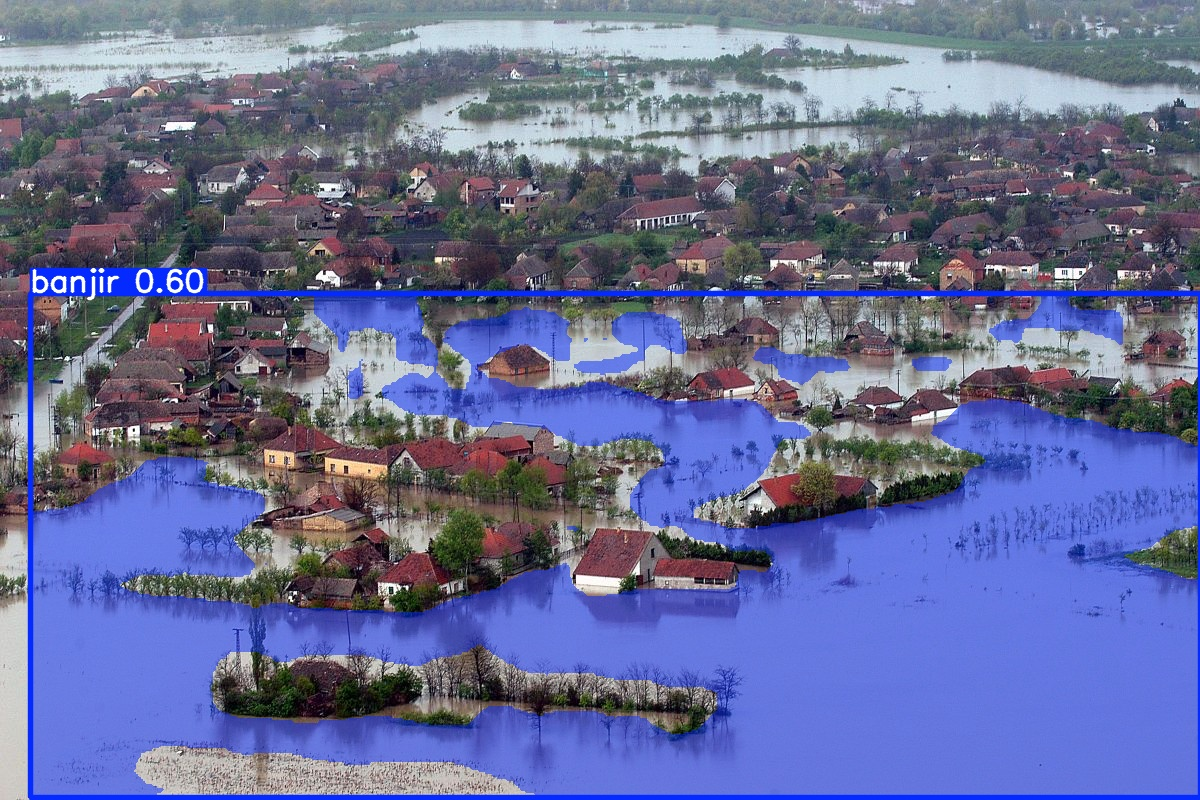

In [ ]:
import glob
from IPython.display import display, Image
import matplotlib.pyplot as plt
import cv2

# Load bobot (otak) terbaik hasil training kita tadi
best_model = YOLO('runs/segment/train/weights/best.pt')

# Ambil gambar pertama dari folder validasi
val_images = glob.glob(f"{yolo_base}/images/val/*.jpg")
test_image = val_images[0]

print(f"Menguji gambar: {test_image}")

# Lakukan prediksi (conf=0.5 artinya hanya tampilkan jika model yakin >50%)
# Hasilnya otomatis disimpan ke folder runs/segment/predict/
prediction = best_model.predict(source=test_image, conf=0.5, save=True, show=False)

# Dapatkan path gambar hasil prediksi terbaru
predict_folder = glob.glob("runs/segment/predict*")
latest_predict_folder = max(predict_folder, key=os.path.getctime)
result_image_path = glob.glob(f"{latest_predict_folder}/*.jpg")[0]

# Tampilkan hasilnya
display(Image(filename=result_image_path))

In [ ]:
import cv2
import numpy as np

# Pastikan menggunakan model terbaik dari hasil training
best_model = YOLO('runs/segment/train/weights/best.pt')

# Global Metrics
total_intersection = 0
total_union = 0
total_tp = 0
total_fp = 0
total_fn = 0

print("Evaluating YOLO model on Validation Data (Pixel-by-Pixel)...")

# Kita iterasi pada data validasi (val_df yang kita buat di Cell 3)
for idx, row in val_df.iterrows():
    img_name = row.iloc[0]
    mask_name = row.iloc[1]

    img_path = os.path.join(image_dir, img_name)
    mask_path = os.path.join(mask_dir, mask_name)

    # 1. Load Ground Truth Mask Asli
    image = cv2.imread(img_path)
    if image is None: continue
    H, W = image.shape[:2]

    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt_mask = cv2.resize(gt_mask, (W, H), interpolation=cv2.INTER_NEAREST)
    gt_mask = (gt_mask > 127).astype(np.float32) # Normalisasi ke 0 dan 1

    # 2. Lakukan Prediksi dengan YOLO
    # verbose=False agar tidak print log per gambar dan memenuhi layar
    results = best_model.predict(source=img_path, imgsz=512, conf=0.5, verbose=False)
    result = results[0]

    # 3. Ubah Prediksi YOLO (Poligon) menjadi Mask Biner (Hitam Putih)
    pred_mask = np.zeros((H, W), dtype=np.float32)

    # Jika YOLO menemukan banjir (masks tidak kosong)
    if result.masks is not None:
        # result.masks.xy berisi koordinat titik-titik poligon
        for poly in result.masks.xy:
            poly_pts = np.array(poly, dtype=np.int32)
            # Gambar poligon di atas pred_mask dan isi dengan nilai 1 (putih)
            cv2.fillPoly(pred_mask, [poly_pts], 1.0)

    # 4. Hitung Metrik (Sama persis dengan logikamu di U-Net)
    gt_flat = gt_mask.flatten()
    pred_flat = pred_mask.flatten()

    intersection = np.sum(pred_flat * gt_flat)
    union = np.sum(pred_flat) + np.sum(gt_flat) - intersection

    total_intersection += intersection
    total_union += union

    total_tp += intersection
    total_fp += np.sum(pred_flat * (1 - gt_flat))
    total_fn += np.sum((1 - pred_flat) * gt_flat)

# 5. Kalkulasi Skor Akhir
# Ditambah 1e-8 untuk menghindari error pembagian dengan nol
mean_iou = total_intersection / (total_union + 1e-8)
mean_precision = total_tp / (total_tp + total_fp + 1e-8)
mean_recall = total_tp / (total_tp + total_fn + 1e-8)
f1_score = 2 * (mean_precision * mean_recall) / (mean_precision + mean_recall + 1e-8)

print(f"--- YOLO Evaluation Results (Validation Set) ---")
print(f"Mean IoU:       {mean_iou:.4f}")
print(f"Mean Precision: {mean_precision:.4f}")
print(f"Mean Recall:    {mean_recall:.4f}")
print(f"F1-Score:       {f1_score:.4f}")

Evaluating YOLO model on Validation Data (Pixel-by-Pixel)...
--- YOLO Evaluation Results (Validation Set) ---
Mean IoU:       0.6589
Mean Precision: 0.8496
Mean Recall:    0.7460
F1-Score:       0.7944


In [ ]:
import cv2
import numpy as np
import os
# 1. Cari folder training yang paling terakhir dibuat secara otomatis
train_folders = glob.glob('runs/segment/train*')
latest_train_folder = max(train_folders, key=os.path.getctime)
best_weights_path = os.path.join(latest_train_folder, 'weights/best.pt')

print(f"Memuat model dari folder: {best_weights_path}")
best_model = YOLO(best_weights_path)

# Variabel untuk menampung metrik keseluruhan
total_intersection = 0
total_union = 0
total_tp = 0
total_fp = 0
total_fn = 0

print("Memulai Evaluasi YOLO secara Pixel-by-Pixel pada Data Validasi...")

# Variabel untuk menampung metrik keseluruhan
total_intersection = 0
total_union = 0
total_tp = 0
total_fp = 0
total_fn = 0

print("Memulai Evaluasi YOLO secara Pixel-by-Pixel pada Data Validasi...")

# 2. Iterasi pada seluruh data validasi (val_df)
for idx, row in val_df.iterrows():
    img_name = row.iloc[0]
    mask_name = row.iloc[1]

    img_path = os.path.join(image_dir, img_name)
    mask_path = os.path.join(mask_dir, mask_name)

    # Load gambar asli untuk mendapatkan dimensi (Tinggi x Lebar)
    image = cv2.imread(img_path)
    if image is None: continue
    H, W = image.shape[:2]

    # Load Mask Asli (Ground Truth) dan ubah ke biner (0 dan 1)
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt_mask = cv2.resize(gt_mask, (W, H), interpolation=cv2.INTER_NEAREST)
    gt_mask = (gt_mask > 127).astype(np.float32)

    # 3. Lakukan Prediksi dengan YOLO (tanpa print log agar rapi)
    results = best_model.predict(source=img_path, imgsz=512, conf=0.5, verbose=False)
    result = results[0]

    # 4. Buat kanvas kosong dan gambar poligon YOLO di atasnya
    pred_mask = np.zeros((H, W), dtype=np.float32)

    if result.masks is not None:
        for poly in result.masks.xy:
            poly_pts = np.array(poly, dtype=np.int32)
            cv2.fillPoly(pred_mask, [poly_pts], 1.0) # Isi area banjir dengan angka 1

    # 5. Hitung metrik persis seperti di U-Net
    gt_flat = gt_mask.flatten()
    pred_flat = pred_mask.flatten()

    intersection = np.sum(pred_flat * gt_flat)
    union = np.sum(pred_flat) + np.sum(gt_flat) - intersection

    total_intersection += intersection
    total_union += union

    total_tp += intersection
    total_fp += np.sum(pred_flat * (1 - gt_flat))
    total_fn += np.sum((1 - pred_flat) * gt_flat)

# 6. Kalkulasi Skor Rata-rata Akhir
mean_iou = total_intersection / (total_union + 1e-8)
mean_precision = total_tp / (total_tp + total_fp + 1e-8)
mean_recall = total_tp / (total_tp + total_fn + 1e-8)
f1_score = 2 * (mean_precision * mean_recall) / (mean_precision + mean_recall + 1e-8)

# Ambil nama folder eksperimen secara dinamis (misal: 'train2', 'train3')
experiment_name = os.path.basename(latest_train_folder)

print(f"\n--- Hasil Akhir Evaluasi Model ({experiment_name}) ---")
print(f"Mean IoU       : {mean_iou:.4f}")
print(f"Mean Precision : {mean_precision:.4f}")
print(f"Mean Recall    : {mean_recall:.4f}")
print(f"F1-Score       : {f1_score:.4f}")

Memuat model dari folder: runs/segment/train4/weights/best.pt
Memulai Evaluasi YOLO secara Pixel-by-Pixel pada Data Validasi...
Memulai Evaluasi YOLO secara Pixel-by-Pixel pada Data Validasi...

--- Hasil Akhir Evaluasi Model (train4) ---
Mean IoU       : 0.3144
Mean Precision : 0.8705
Mean Recall    : 0.3299
F1-Score       : 0.4784
